# analysis_b / 02 — Lexical Exploration (Purely Descriptive)

No partition, no seed vocabulary, no Fightin' Words. This notebook describes what the corpus *is* — its vocabulary structure, collocations, and embedding geometry — without imposing a pre-theoretical split.

**Pipeline:** corpus load → vocabulary stats → Zipf & coverage → bigram/trigram inspection → spaCy embedding nearest neighbors → PCA scatter

**Reads:** `../artifacts/posts_clean.parquet`  
**Writes:** nothing (exploratory only)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path
from collections import Counter
from itertools import islice

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
%matplotlib inline

ARTIFACTS = Path('artifacts')
df = pd.read_parquet(ARTIFACTS / 'posts_clean.parquet')

print(f'Loaded {len(df):,} posts')
df[['text_lemma', 'score', 'year_month']].head(3)

Loaded 4,856 posts


,text_lemma,score,year_month
0,sure right subreddit friend try start actually...,3,2026-03
1,remember change flair reflect appropriate flai...,1,2026-03
2,remember post situation figure post weird situ...,10,2026-03


## 1. Vocabulary Stats

Unigram frequency table over the full lemmatized corpus. Key numbers to read off:

- **Total tokens** and **unique terms** — corpus size and lexical richness
- **Hapax legomena** (freq = 1) — how much of the vocabulary is unique to single posts; a high proportion is normal in social-media text
- **min_df thresholds** — guides `CountVectorizer` settings downstream

In [2]:
all_tokens = [t for tokens in df['tokens'] for t in tokens]
term_freq  = Counter(all_tokens)

freq_df         = pd.DataFrame(term_freq.most_common(), columns=['term', 'freq'])
freq_df['rank'] = range(1, len(freq_df) + 1)

print(f'Total tokens (all posts)  : {len(all_tokens):,}')
print(f'Unique terms in corpus    : {len(freq_df):,}')
print(f'Hapax legomena  (freq=1)  : {(freq_df["freq"] == 1).sum():,}')
print(f'Terms with freq >= 5      : {(freq_df["freq"] >= 5).sum():,}')
print(f'Terms with freq >= 10     : {(freq_df["freq"] >= 10).sum():,}')
print()
print('Top 30 terms:')
print(freq_df.head(30).to_string(index=False))

Total tokens (all posts)  : 192,339
Unique terms in corpus    : 10,560
Hapax legomena  (freq=1)  : 4,601
Terms with freq >= 5      : 3,219
Terms with freq >= 10     : 2,030

Top 30 terms:
      term  freq  rank
     thing  1551     1
     flair  1544     2
      time  1518     3
      know  1471     4
       see  1360     5
     think  1305     6
      post  1289     7
     house  1237     8
experience  1200     9
    happen  1196    10
      feel  1151    11
    people  1141    12
  remember  1126    13
 subreddit  1099    14
      look  1058    15
      read  1030    16
      like  1010    17
       get   980    18
  question   974    19
      year   964    20
    change   943    21
      hear   940    22
       say   928    23
      well   914    24
   mention   909    25
      come   900    26
     image   882    27
   contact   857    28
      room   854    29
   include   850    30


A preliminary though is that maybe we find clusters around experiences and other about spaces or context in which the situation happens

a deeper inspection should reveal more info
* Maybe clusters(?)
* Proceed with LDA and LTA


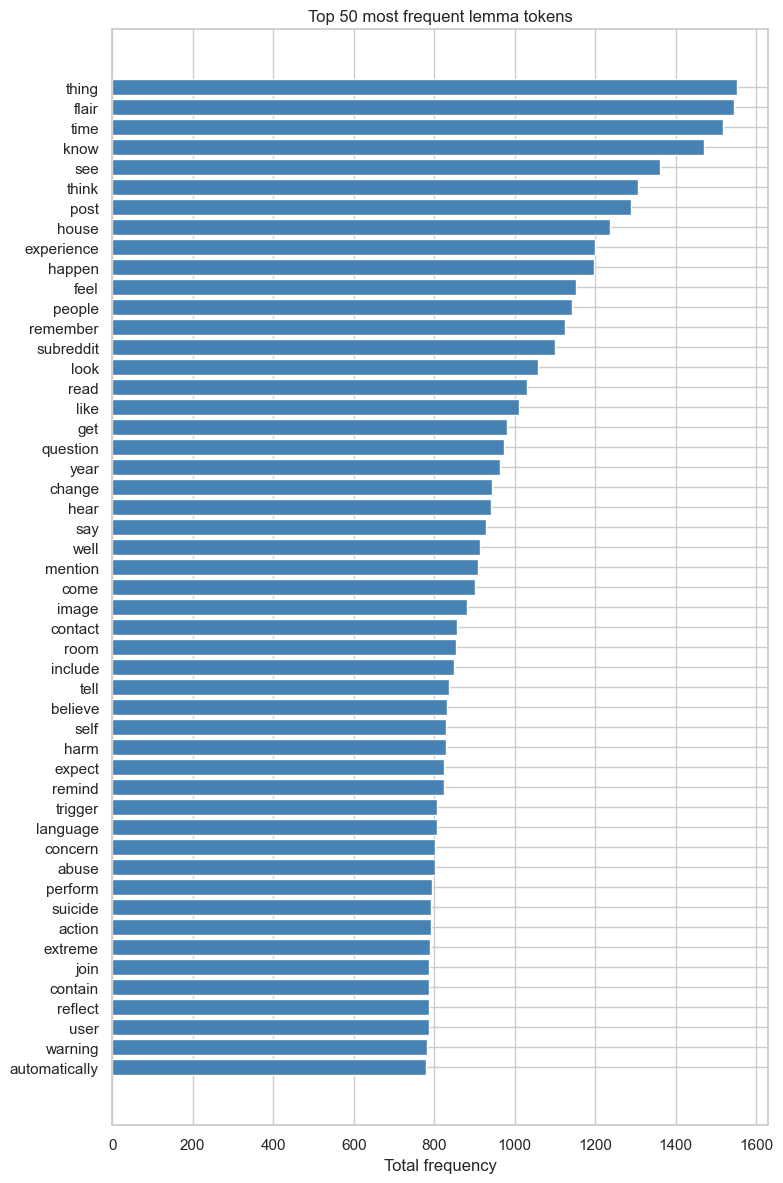

In [3]:
top50 = freq_df.head(50).iloc[::-1]

fig, ax = plt.subplots(figsize=(8, 12))
ax.barh(top50['term'], top50['freq'], color='steelblue')
ax.set_title('Top 50 most frequent lemma tokens')
ax.set_xlabel('Total frequency')
plt.tight_layout()
plt.show()

## 2. Zipf & Coverage

- **Left:** rank-frequency log-log plot. A straight line confirms the power-law distribution is intact after POS filtering.
- **Right:** cumulative vocabulary coverage. Read off how many unique terms are needed to cover 50 / 90 / 95 % of all tokens — this informs the `min_df` cutoff for any downstream vectorization.

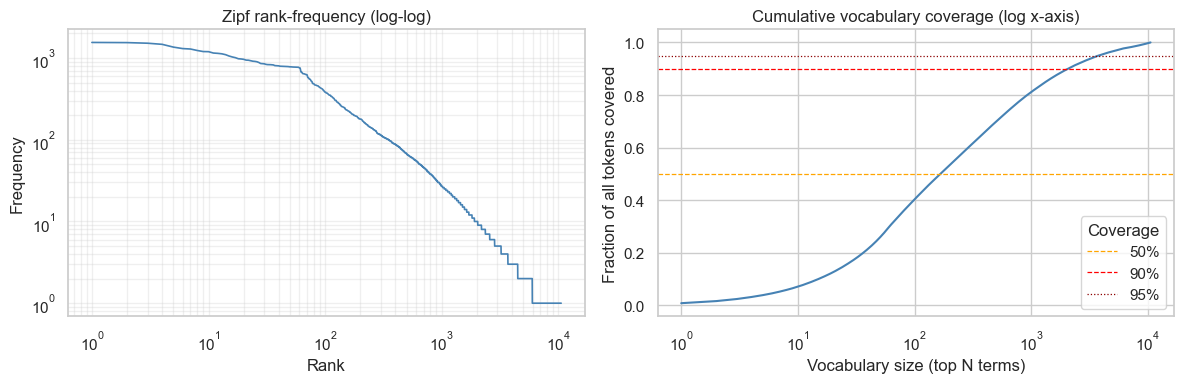

Coverage thresholds:
  Top   167 terms cover 50% of all tokens
  Top   926 terms cover 80% of all tokens
  Top 2,068 terms cover 90% of all tokens
  Top 3,792 terms cover 95% of all tokens


In [4]:
cumulative = freq_df['freq'].cumsum() / freq_df['freq'].sum()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.loglog(freq_df['rank'], freq_df['freq'], linewidth=1.2, color='steelblue')
ax1.set_title('Zipf rank-frequency (log-log)')
ax1.set_xlabel('Rank')
ax1.set_ylabel('Frequency')
ax1.grid(True, which='both', alpha=0.3)

ax2.semilogx(freq_df['rank'], cumulative, linewidth=1.5, color='steelblue')
for pct, col, ls in [(0.50, 'orange', '--'), (0.90, 'red', '--'), (0.95, 'darkred', ':')]:
    ax2.axhline(pct, color=col, linestyle=ls, linewidth=0.9, label=f'{pct:.0%}')
ax2.set_title('Cumulative vocabulary coverage (log x-axis)')
ax2.set_xlabel('Vocabulary size (top N terms)')
ax2.set_ylabel('Fraction of all tokens covered')
ax2.legend(title='Coverage')

plt.tight_layout()
plt.show()

print('Coverage thresholds:')
for pct in (0.50, 0.80, 0.90, 0.95):
    n = int((cumulative < pct).sum()) + 1
    print(f'  Top {n:5,} terms cover {pct:.0%} of all tokens')

## 3. N-gram Inspection

Bigrams and trigrams from the lemmatized token lists (POS-filtered, stopword-removed). These collocations reveal multi-word patterns — narrative formulas, recurring sensory descriptions, common event phrases — that unigrams miss.

Unique bigrams  : 113,968
Unique trigrams : 145,354


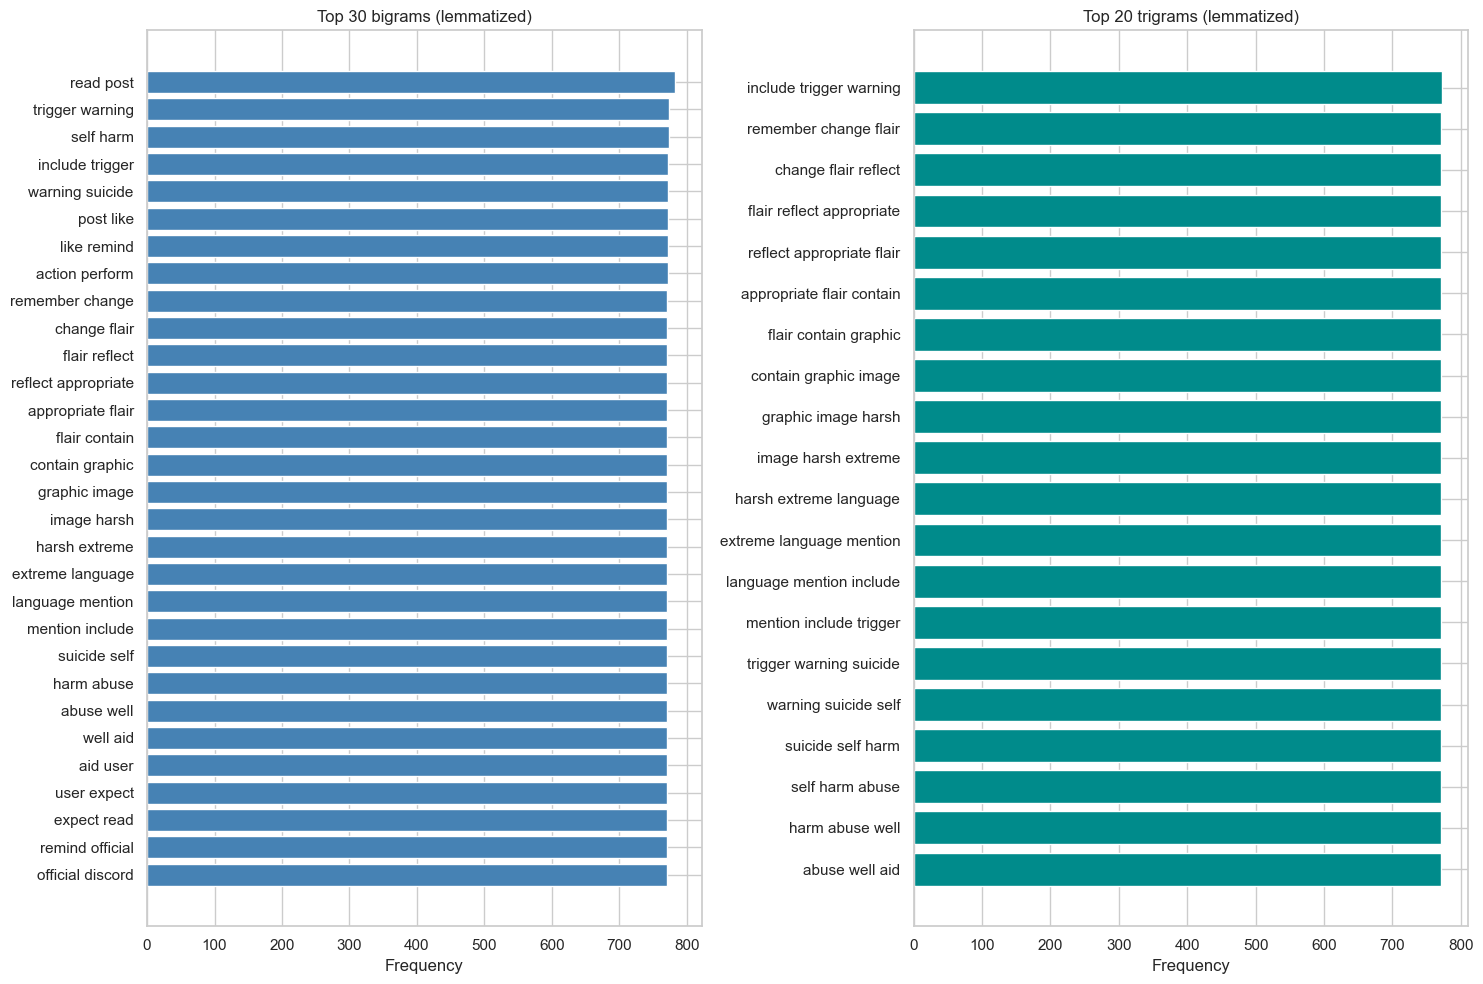

In [5]:
def make_ngrams(tokens, n):
    return list(zip(*[tokens[i:] for i in range(n)]))

all_bigrams  = [bg for toks in df['tokens'] for bg in make_ngrams(toks, 2)]
all_trigrams = [tg for toks in df['tokens'] for tg in make_ngrams(toks, 3)]

bi_freq  = Counter(' '.join(bg) for bg in all_bigrams)
tri_freq = Counter(' '.join(tg) for tg in all_trigrams)

bi_df  = pd.DataFrame(bi_freq.most_common(50),  columns=['ngram', 'freq'])
tri_df = pd.DataFrame(tri_freq.most_common(30),  columns=['ngram', 'freq'])

print(f'Unique bigrams  : {len(bi_freq):,}')
print(f'Unique trigrams : {len(tri_freq):,}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 10))

top_bi  = bi_df.head(30).iloc[::-1]
top_tri = tri_df.head(20).iloc[::-1]

ax1.barh(top_bi['ngram'],  top_bi['freq'],  color='steelblue')
ax1.set_title('Top 30 bigrams (lemmatized)')
ax1.set_xlabel('Frequency')

ax2.barh(top_tri['ngram'], top_tri['freq'], color='darkcyan')
ax2.set_title('Top 20 trigrams (lemmatized)')
ax2.set_xlabel('Frequency')

plt.tight_layout()
plt.show()

### 3.1 Bigrams by TF-IDF weight

Raw frequency favours very common collocations. TF-IDF bigrams surface phrases that are frequent *and* distinctive — less dominated by generic narrative glue.

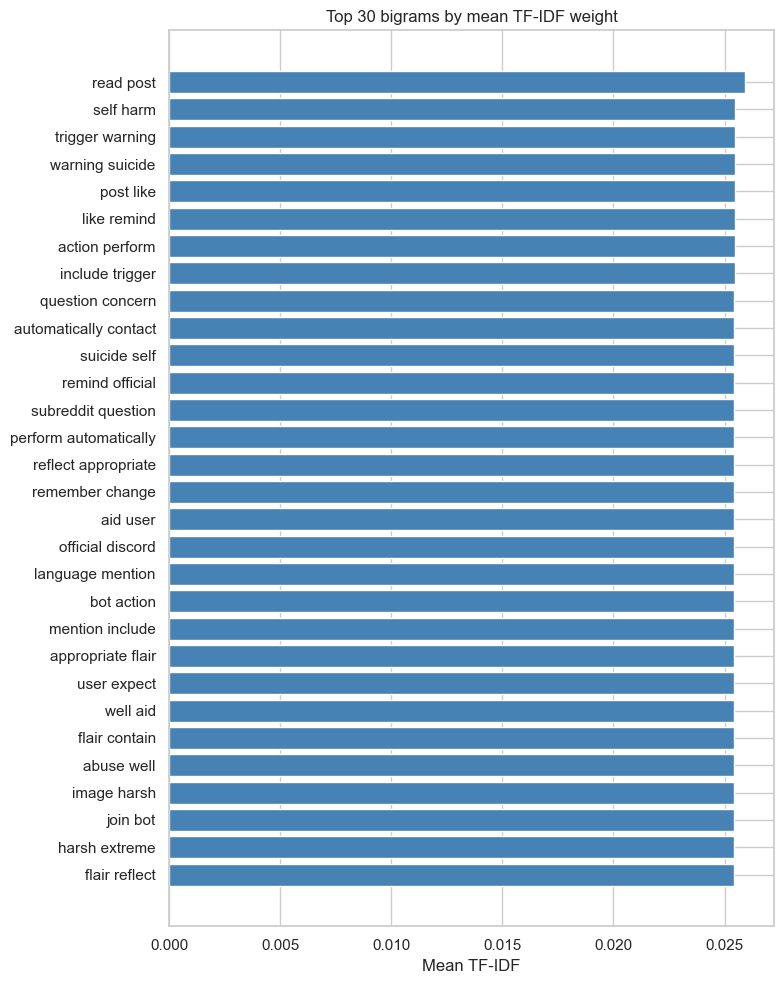

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_bi = TfidfVectorizer(ngram_range=(2, 2), min_df=5, max_df=0.90)
tfidf_bi.fit(df['text_lemma'])

tfidf_scores = tfidf_bi.idf_  # IDF gives global distinctiveness
bi_names     = tfidf_bi.get_feature_names_out()

# Combine: mean TF-IDF across all docs
tfidf_mat    = tfidf_bi.transform(df['text_lemma'])
mean_tfidf   = np.asarray(tfidf_mat.mean(axis=0)).flatten()

tfidf_bi_df = pd.DataFrame({'bigram': bi_names, 'mean_tfidf': mean_tfidf})
tfidf_bi_df = tfidf_bi_df.sort_values('mean_tfidf', ascending=False).head(30)

plot_tfidf = tfidf_bi_df.iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 10))
ax.barh(plot_tfidf['bigram'], plot_tfidf['mean_tfidf'], color='steelblue')
ax.set_title('Top 30 bigrams by mean TF-IDF weight')
ax.set_xlabel('Mean TF-IDF')
plt.tight_layout()
plt.show()

## 4. Embedding Inspection (spaCy `en_core_web_lg`)

Two views using the 300-dim GloVe vectors bundled with `en_core_web_lg`:

- **Nearest neighbors** — for a set of probe words drawn from the top-50 corpus terms, the 12 closest terms *within the corpus vocabulary* by cosine similarity. Reveals semantic clusters without imposing a partition.
- **PCA scatter** — top-200 corpus terms projected to 2D. Color encodes log-frequency. Look for natural groupings.

In [7]:
import spacy

nlp = spacy.load('en_core_web_lg',
                 exclude=['tok2vec', 'tagger', 'parser', 'ner', 'attribute_ruler', 'lemmatizer'])

TOP_VEC   = 500
top_terms = freq_df.head(TOP_VEC)['term'].tolist()
vectors   = {}
for w in top_terms:
    lex = nlp.vocab[w]
    if lex.has_vector:
        vectors[w] = lex.vector

terms_arr = list(vectors.keys())
vec_mat   = np.array([vectors[w] for w in terms_arr])

print(f'Terms with spaCy vectors: {len(vectors):,} / {TOP_VEC}')

def nearest_neighbors(word, n=12):
    if word not in vectors:
        return [f'[{word} not in top-{TOP_VEC} vocab]']
    query      = vectors[word]
    query_norm = np.linalg.norm(query)
    if query_norm == 0:
        return []
    dots  = vec_mat @ query
    norms = np.linalg.norm(vec_mat, axis=1) * query_norm + 1e-8
    sims  = dots / norms
    if word in terms_arr:
        sims[terms_arr.index(word)] = -np.inf
    top_idx = sims.argsort()[::-1][:n]
    return [terms_arr[i] for i in top_idx]

Terms with spaCy vectors: 500 / 500


In [8]:
# Probe words: top-20 corpus terms that have vectors
PROBE_WORDS = [w for w in freq_df.head(30)['term'] if w in vectors][:20]

print('Nearest neighbors in corpus vocabulary (top-500 terms)')
print('=' * 65)
for word in PROBE_WORDS:
    nbrs = nearest_neighbors(word)
    print(f'{word:15s}: {', '.join(nbrs)}')

Nearest neighbors in corpus vocabulary (top-500 terms)
thing          : think, reason, kind, thought, know, idea, guess, way, actually, wonder, maybe, sure
flair          : flare, sense, spirit, touch, detail, attention, dress, great, kitchen, kind, experience, fine
time           : day, moment, wait, start, way, place, long, sure, one, work, able, happen
know           : think, tell, sure, understand, say, want, believe, guess, wonder, thought, remember, thing
see            : know, look, sure, think, tell, want, find, get, let, like, wonder, way
think          : know, guess, thought, believe, say, maybe, wonder, actually, thing, sure, probably, imagine
post           : comment, interesting, read, idea, check, see, week, point, mention, sure, write, sorry
house          : home, apartment, bedroom, basement, room, kitchen, building, floor, property, living, family, bathroom
experience     : well, feel, great, life, work, understand, sense, especially, time, able, learn, mind
happen    

## 5. PCA Scatter

Top-200 corpus terms projected to 2D by PCA on their 300-dim spaCy vectors. Color encodes log corpus frequency (darker = more frequent). Natural clusters here reflect genuine semantic proximity, not a pre-imposed partition.

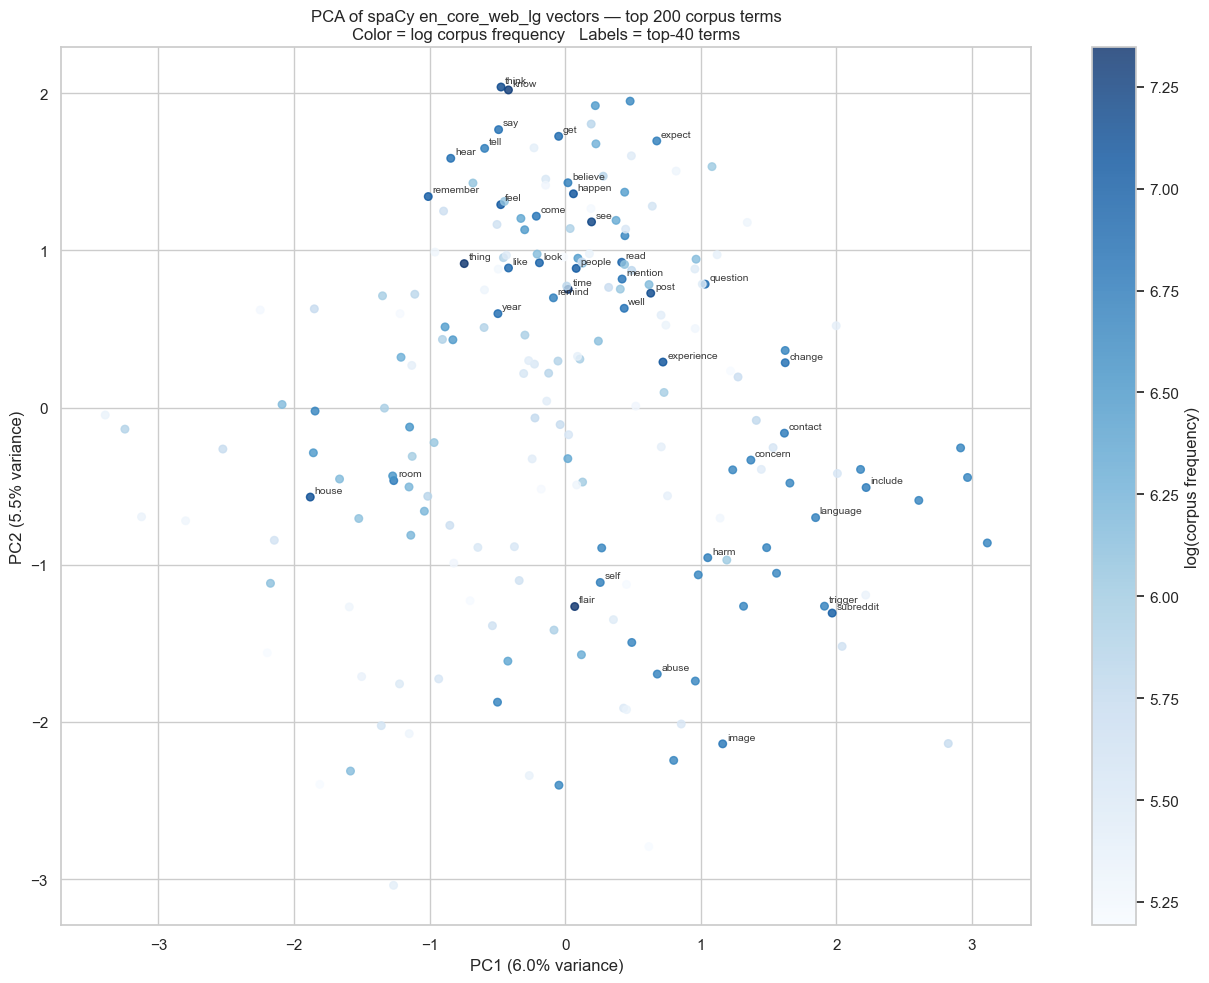

In [9]:
from sklearn.decomposition import PCA

TOP_PLOT   = 200
terms_plot = [w for w in freq_df.head(TOP_PLOT + 50)['term'] if w in vectors][:TOP_PLOT]
mat_plot   = np.array([vectors[w] for w in terms_plot])
freq_vals  = np.array([term_freq[w] for w in terms_plot], dtype=float)
log_freq   = np.log1p(freq_vals)

pca = PCA(n_components=2, random_state=42)
xy  = pca.fit_transform(mat_plot)

fig, ax = plt.subplots(figsize=(13, 10))
sc = ax.scatter(xy[:, 0], xy[:, 1],
                c=log_freq, cmap='Blues', s=30, alpha=0.80, zorder=2)
plt.colorbar(sc, ax=ax, label='log(corpus frequency)')

# Label top-40 most frequent terms
label_set = set(terms_plot[:40])
for i, w in enumerate(terms_plot):
    if w in label_set:
        ax.annotate(w, (xy[i, 0], xy[i, 1]), fontsize=7.5, alpha=0.9,
                    xytext=(3, 3), textcoords='offset points')

ax.set_title(
    f'PCA of spaCy en_core_web_lg vectors — top {len(terms_plot)} corpus terms\n'
    'Color = log corpus frequency   Labels = top-40 terms'
)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.tight_layout()
plt.show()

## 6. Observations

*(Fill in after running all cells.)*

**Vocabulary:**
- Most frequent terms:
- Dominant bigrams:
- Notable trigrams:

**Embedding structure:**
- Visible clusters in PCA:
- Interesting nearest-neighbor groupings:

**What the corpus seems to be about (without a pre-imposed framework):**
- 
